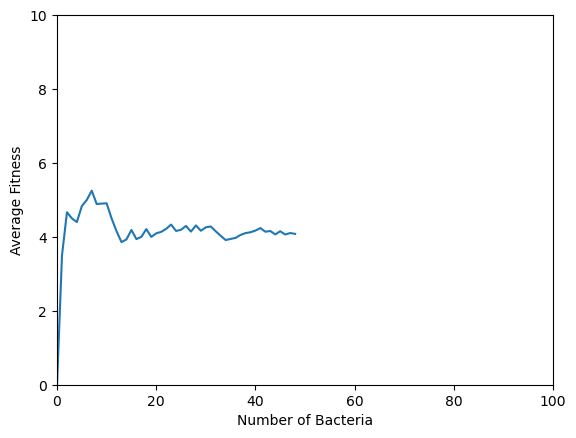

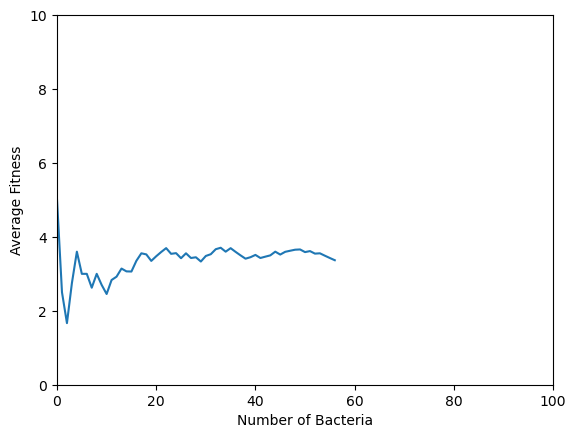

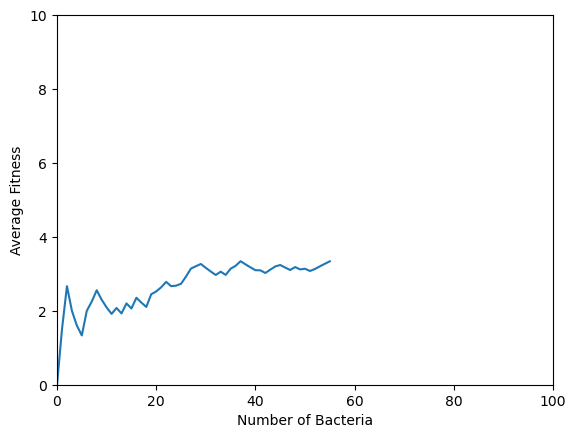

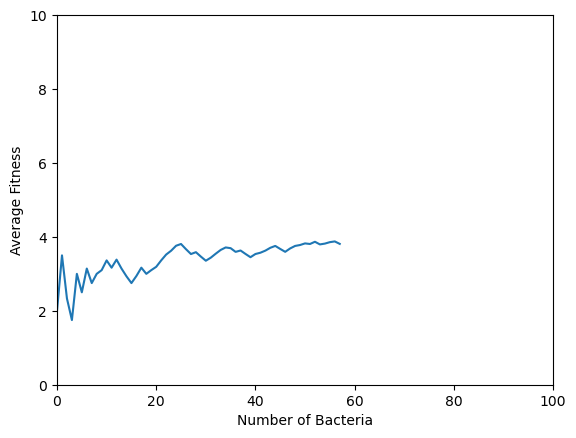

In [8]:
#Importing Files

import matplotlib.pyplot as plt
import numpy as np
import random

def survival_probability_range(a):
    GC_ratio = a / 10
    survival_probability = 0.18 + 0.78 * GC_ratio
    return survival_probability

    
NUMBER_OF_GENERATIONS = 4
for generations in range(NUMBER_OF_GENERATIONS):
    
    #Necessary storage data
    
    Bacteria = {}
    genes = [1, 2, 3, 4]
    DNA = np.empty((0, 10))
    fitness_rating = []
    
    # Phase 1 : Creating Bacteria and storing general information
    
    for abcd in range(100):
        Each_bacteria_DNA = []
        for abcde in range(10):
            bacteria_DNA = random.choice(genes)
            Each_bacteria_DNA.append(bacteria_DNA)
        DNA = np.append(DNA, [list(Each_bacteria_DNA)], axis = 0)
    
    for row_index, row in enumerate(DNA):
        fit_count = 0
        for col_index, val in enumerate(row):
            if val == 3 or val == 4:
                fit_count += 1
        fitness = fit_count
        fitness_rating.append(fitness)
    
    for bacteria_info in range(100):
        ID = bacteria_info
        Bacteria[ID] = {
            "DNA" : DNA[ID],
            "Fitness" : fitness_rating[ID],
        }
    
    
    #Phase 2 : Mutation Phase
    
    Mutated_Bacteria = {}
    
    for ID in Bacteria:
        Mutated_bacteria = []
        for g in range(len(Bacteria[ID]["DNA"])):
            current_DNA = Bacteria[ID]["DNA"][g]
            if random.random() <= 0.05:
                mutated_DNA = random.choice(genes)
                if mutated_DNA != current_DNA:
                    current_DNA = mutated_DNA
            Mutated_bacteria.append(current_DNA)
    
        fit_count = 0
        for gene in Mutated_bacteria:
            if gene in [3, 4]:
                fit_count += 1
    
        Mutated_Bacteria[ID] = {
        "DNA" : Mutated_bacteria,
        "Fitness" : fit_count
        }
    Bacteria = Mutated_Bacteria
    
    
    #Phase 3 : Survival and Evolution

    Bacteria_Survived = {}
    
    for ID in Bacteria:
        if random.random() < survival_probability_range(Bacteria[ID]["Fitness"]):
            Bacteria_Survived[ID] = {
                "DNA" : Bacteria[ID]["DNA"],
                "Fitness" : Bacteria[ID]["Fitness"]
            }
    Bacteria = Bacteria_Survived


    #Phase 4: Reproduction

    Offspring = {}
    
    for ID in Bacteria:
        DNA_offspring = []
        if random.random() < survival_probability_range(Bacteria[ID]["Fitness"]):
            for i in range(len(Bacteria[ID]["DNA"])):
                parent_DNA = Bacteria[ID]["DNA"][i]
                if random.random() <= 0.05:
                    final_DNA = random.choice(genes)
                else:
                    final_DNA = parent_DNA
                DNA_offspring.append(final_DNA)

        fit_count = 0
        for gene in DNA_offspring:
            if gene in [3, 4]:
                fit_count += 1
                
        Offspring[ID] = {
        "DNA" : DNA_offspring,
        "Fitness" : fit_count
        }
    Bacteria = Offspring


    #Plotting Observations
    average_FIT = []
    total_fitness = 0
    count = 0
    
    for ID in Bacteria:
        total_fitness += Bacteria[ID]["Fitness"]
        count += 1
        avg = total_fitness / count
        average_FIT.append(avg)

    xAxis = list(range(len(average_FIT)))

    plt.xlabel("Number of Bacteria")
    plt.ylabel("Average Fitness")
    plt.ylim(0,10)
    plt.xlim(0,100)
    plt.plot(xAxis, average_FIT)
    plt.show()